# **Customer Behaviour and Shopping Analysis**

Muhammad Ibrahim Kamil | 2509116012

# **Import Library**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from sklearn.impute import KNNImputer

# **Bussiness Understanding**

## **Bussiness Objective**

[Analisis Perilaku Belanja Pelanggan]

Analisis pada dataset Customer Shopping Behavior ini bertujuan untuk membantu manajemen dalam memahami pola konsumsi, preferensi produk, serta loyalitas pelanggan guna meningkatkan efisiensi operasional dan profitabilitas perusahaan. Fokus utama analisis ini mencakup evaluasi mendalam terhadap segmentasi demografis (Usia dan Jenis Kelamin) serta pengaruhnya terhadap kategori produk yang diminati (Clothing, Footwear, Accessories, dll) di berbagai wilayah (Location).

Sebagai bisnis retail yang kompetitif, diperlukan pendekatan berbasis data untuk mengidentifikasi korelasi antara status Subscription dengan frekuensi belanja dan total pengeluaran (Purchase Amount). Selain itu, analisis ini bertujuan memetakan tren belanja musiman (Season) dan efektivitas penggunaan promo/diskon terhadap kepuasan pelanggan yang tercermin pada Review Rating. Hasil akhir dari analisis ini diharapkan dapat memberikan wawasan strategis mengenai target pasar potensial, optimasi stok barang berdasarkan musim, serta perancangan program loyalitas yang lebih personal dan tepat sasaran.

## **Asses Situation**

Situasi saat ini menunjukkan dominasi pelanggan pria (68%) dengan kategori *Clothing* sebagai kontributor utama, namun loyalitas masih rendah karena angka *subscription* baru menyentuh 27%. Strategi ke depan harus fokus pada konversi member melalui program loyalitas dan optimasi layanan di wilayah dengan transaksi tinggi seperti Montana dan California.

## **Analytic Goals Project Plan**

Rencana proyek ini mencakup langkah-langkah terstruktur dari pengolahan data hingga penyajian hasil untuk mencapai tujuan bisnis yang telah ditetapkan:


*   Pengumpulan dan Eksplorasi Data: Memahami struktur dataset perilaku belanja, termasuk variabel demografi, kategori produk, dan nominal transaksi.
*   Pembersihan Data: Melakukan validasi data, menangani missing values, serta memastikan tipe data pada kolom seperti Purchase Amount dan Age sudah sesuai untuk analisis.

Tujuan utama dari analisis data ini adalah untuk menghasilkan wawasan yang dapat ditindaklanjuti guna meningkatkan efisiensi pemasaran dan loyalitas pelanggan. Secara spesifik, tujuan yang ingin dicapai adalah:



*   Mengidentifikasi Karakteristik Pelanggan Potensial
*   Menganalisis Efektivitas Program Subscription dan Diskon
*   Evaluasi Kontribusi Lokasi dan Kategori Produk
*   Memahami Pola Pembelian Musiman
*   Menghasilkan Visualisasi yang Komunikatif sebagai Alat Bantu Strategis







# **Data Understanding**

## **Memuat Dataset**

Sumber dataset ini berasal dari Dataset Customer Behaviour and shopping Analysis, yang bertujuan untuk menganalisis Perilaku kustomer saat berbelanja

In [2]:
file = "/content/drive/MyDrive/Dataset Pratikum AVD/shopping_behavior_updated.csv"
df = pd.read_csv(file)

df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


## **Deskripsi Data**

### **Informasi Dasar**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

Bedasarkan data di atas, dapat diketahui bahwa dataset ini memiliki 3900 Baris dan 18 Kolom

### **Informasi Lanjutan**

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   



1.   Customer ID: Jumlah baris: 3900 Tipe data: int64 Deskripsi: ID unik untuk setiap pelanggan

1.   Age: Jumlah baris: 3900 Tipe data: int64 Deskripsi: Usia pelanggan

1.   Gender: Jumlah baris: 3900 Tipe data: object Deskripsi: Jenis kelamin pelanggan

1.   Item Purchased: Jumlah baris: 3900 Tipe data: object Deskripsi: Nama produk yang dibeli

1.   Category: Jumlah baris: 3900 Tipe data: object Deskripsi: Kategori produk

1.  Purchase Amount (USD): Jumlah baris: 3900 Tipe data: int64 Deskripsi: Nilai transaksi dalam mata uang USD

1.   Location: Jumlah baris: 3900 Tipe data: object Deskripsi: Lokasi atau negara bagian tempat pembelian

1.   Size: Jumlah baris: 3900 Tipe data: object Deskripsi: Ukuran produk yang dibeli

1.   Color: Jumlah baris: 3900 Tipe data: object Deskripsi: Warna produk yang dibeli
2.   Season: Jumlah baris: 3900 Tipe data: object Deskripsi: Musim saat transaksi terjadi


2.   Review Rating: Jumlah baris: 3900 Tipe data: float64 Deskripsi: Penilaian pelanggan terhadap produk


2.   Subscription Status: Jumlah baris: 3900 Tipe data: object Deskripsi: Status keanggotaan/langganan pelanggan


2.   Shipping Type: Jumlah baris: 3900 Tipe data: object Deskripsi: Metode pengiriman yang digunakan


2.   Discount Applied: Jumlah baris: 3900 Tipe data: object Deskripsi: Keterangan apakah ada diskon yang diterapkan


2.   Promo Code Used: Jumlah baris: 3900 Tipe data: object Deskripsi: Keterangan penggunaan kode promo


2.   Previous Purchases: Jumlah baris: 3900 Tipe data: int64 Deskripsi: Jumlah transaksi yang dilakukan sebelumnya


2.   Payment Method: Jumlah baris: 3900 Tipe data: object Deskripsi: Metode pembayaran yang digunakan


2.   Frequency of Purchases: Jumlah baris: 3900 Tipe data: object Deskripsi: Seberapa sering pelanggan berbelanja



### **Informasi Statistik Deskriptif**

In [11]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


1. Count (Kelengkapan Data)
Berdasarkan data, total baris transaksi adalah 3.900. Maka dapat disimpulkan:

Tidak ada data yang hilang (missing values) pada kolom utama.

Semua kolom (seperti Age, Purchase Amount, Review Rating, dll) memiliki 3.900 data lengkap.

Kesimpulan: Dataset ini sangat bersih dan tidak memiliki missing values, sehingga siap digunakan untuk analisis lebih lanjut tanpa perlu proses imputasi data.

---

2. Mean vs Median (Distribusi Data)

Kolom Age (Usia)

Mean = 44,07

Median = 44,00

Distribusi data usia pelanggan sangat simetris karena nilai rata-rata dan nilai tengah hampir identik.

Kolom Purchase Amount (USD)

Mean = 59,76

Median = 60,00

Nilai belanja rata-rata hampir sama dengan median, menunjukkan pengeluaran pelanggan terdistribusi secara merata di kisaran 60 USD.

Kolom Review Rating

Mean = 3,75

Median = 3,70

Tingkat kepuasan pelanggan cenderung stabil di angka 3.7, menunjukkan sentimen yang cukup positif secara umum.

Kesimpulan: Secara keseluruhan, variabel numerik dalam dataset ini memiliki distribusi yang cenderung normal/simetris, di mana tidak terlihat adanya tarikan ekstrem dari nilai outlier yang signifikan.

---

3. Min dan Max (Validasi Logika)

Age

Min = 18

Max = 70

Purchase Amount (USD)

Min = 20

Max = 100

Review Rating

Min = 2,5

Max = 5,0

Previous Purchases

Min = 1

Max = 50

Kesimpulan:

Rentang usia 18-70 tahun menunjukkan target pasar yang luas dari Gen Z hingga Boomers.

Nilai transaksi minimum 20 USD dan maksimal 100 USD menunjukkan bahwa produk yang dijual berada di kategori harga menengah (bukan barang mewah/luxurious item yang sangat mahal).

Rating terendah 2.5 mengindikasikan bahwa secara umum produk diterima dengan cukup baik oleh pasar (tidak ada rating yang sangat buruk di bawah 2.0).

---

4. Standar Deviasi (std) - Variabilitas Data

Purchase Amount (USD)

Mean = 59,76

Std = 23,68

Previous Purchases

Mean = 25,35

Std = 14,45

Kesimpulan:

Pada kolom Purchase Amount, nilai standar deviasi (23,68) menunjukkan variasi harga antar produk yang cukup beragam, namun tetap dalam rentang yang wajar (sekitar 39% dari mean).

Pada kolom Previous Purchases, nilai standar deviasi yang cukup tinggi (14,45) menunjukkan tingkat loyalitas pelanggan yang sangat bervariasi; ada pelanggan baru dengan 1 pembelian dan ada pelanggan sangat loyal dengan total 50 pembelian sebelumnya.

## **VERIFIKASI KUALITAS DATA**

### **Data Type Check**

Kita akan mengecek tipe data dari setiap kolom untuk memastikan konsistensi dan kesesuaian format. Hal ini krusial agar proses pengolahan data, analisis statistik, serta visualisasi yang dihasilkan menjadi akurat. Berdasarkan pengecekan, seluruh kolom telah memiliki tipe data yang sesuai dengan karakteristik nilainya (misalnya Purchase Amount sebagai integer dan Review Rating sebagai float), sehingga data siap untuk dianalisis lebih lanjut tanpa perlu konversi tipe data

In [12]:
df.dtypes

,0
Customer ID,int64
Age,int64
Gender,object
Item Purchased,object
Category,object
Purchase Amount (USD),int64
Location,object
Size,object
Color,object
Season,object


### **Inconsistent Values**

Pada tahap ini, kita perlu mengecek kekonsistenan data, contoh nya dalam penulisan. Hal ini dilakukan agar data tidak terduplikat dengan baris yang sebenarnya sama akan tetapi bisa terduplikat karena tidak konsisten.


*   Item Purchased & Category

Pada kolom-kolom kategorikal seperti Item Purchased dan Category, kita perlu memastikan tidak ada variasi penulisan yang tidak konsisten (seperti "Clothing" dan "clothing"). Penanganan dilakukan dengan memastikan semua teks menggunakan format yang seragam dan menghapus spasi yang tidak perlu, sehingga setiap item terhitung secara tepat dalam analisis tren penjualan.


In [13]:
print(df['Item Purchased'].unique())

['Blouse' 'Sweater' 'Jeans' 'Sandals' 'Sneakers' 'Shirt' 'Shorts' 'Coat'
 'Handbag' 'Shoes' 'Dress' 'Skirt' 'Sunglasses' 'Pants' 'Jacket' 'Hoodie'
 'Jewelry' 'T-shirt' 'Scarf' 'Hat' 'Socks' 'Backpack' 'Belt' 'Boots'
 'Gloves']


In [14]:
print(df['Category'].unique())

['Clothing' 'Footwear' 'Outerwear' 'Accessories']


### **Missing Values**

Langkah ini bertujuan untuk mendeteksi keberadaan data yang hilang di setiap kolom agar tidak mengganggu proses perhitungan statistik. Menggunakan perhitungan rasio:

In [15]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Customer ID,0.0
Age,0.0
Gender,0.0
Item Purchased,0.0
Category,0.0
Purchase Amount (USD),0.0
Location,0.0
Size,0.0
Color,0.0
Season,0.0


Hasil Analisis:

*   Ditemukan bahwa seluruh kolom (18 kolom) memiliki Null Ratio sebesar 0.0%.
*   Hal ini menunjukkan bahwa setiap baris transaksi dari 3.900 data yang tersedia telah terisi secara lengkap tanpa ada informasi yang terlewat.


Kesimpulan:
Karena tidak ditemukan missing values, kita tidak perlu melakukan proses handling (pengisian data kosong). Dataset dinyatakan valid dan siap untuk masuk ke tahap analisis korelasi dan visualisasi.

### **Duplicated Values**

Pengecekan ini bertujuan untuk memastikan tidak ada entri data yang tercatat lebih dari satu kali, yang dapat menyebabkan bias pada hasil analisis akhir. Pengecekan dilakukan menggunakan fungsi:

In [16]:
df[df.duplicated()]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases


Hasil Analisis:

* Hasil eksekusi menunjukkan bahwa tidak
ditemukan baris data yang terduplikat di seluruh dataset (0 duplicated rows).

* Setiap baris dalam dataset ini bersifat unik, yang berarti setiap transaksi mewakili aktivitas belanja yang berbeda dari pelanggan.

Kesimpulan:
Karena tidak adanya data duplikat, integritas data tetap terjaga. Kita tidak perlu melakukan proses penghapusan baris (drop duplicates), sehingga jumlah sampel data tetap utuh sebanyak 3.900 baris untuk dianalisis lebih lanjut.

### **Outliers Values**

**Analisis Outliers**

Pengecekan outliers dilakukan untuk melihat apakah ada data yang nilainya sangat ekstrem (terlalu jauh dari rata-rata) yang dapat merusak model analisis. Kita menggunakan metode Interquartile Range (IQR) dan visualisasi Boxplot.

1. Persentase Outliers (Metode IQR)
Berdasarkan hasil perhitungan pada kolom numerik:

* Age: 0.0%

* Purchase Amount (USD): 0.0%

* Review Rating: 0.0%

* Previous Purchases: 0.0%

Kesimpulan: Tidak ditemukan adanya data outliers pada variabel-variabel utama. Hal ini menandakan data transaksi berada dalam rentang yang wajar dan konsisten.

---

2. Visualisasi Boxplot
(Catatan: Karena kolom Quantity dan Profit tidak ada di dataset ini, kita ganti dengan Purchase Amount dan Review Rating)

*  Boxplot Purchase Amount (USD): Menunjukkan distribusi harga item yang dibeli pelanggan terkonsentrasi di rentang USD 20 hingga USD 100 tanpa ada titik pencilan di luar garis whisker.

* Boxplot Review Rating: Menunjukkan penilaian pelanggan tersebar merata antara 2.5 hingga 5.0, mengonfirmasi tidak ada nilai rating yang aneh atau di luar batas normal.

Kesimpulan Akhir:
Dataset ini memiliki kualitas data yang sangat baik karena tidak memiliki missing values, duplikat, maupun outliers. Dengan kondisi data yang "bersih" ini, hasil analisis statistik selanjutnya akan menjadi lebih reliabel dan akurat.

In [17]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Customer ID,0.0
Age,0.0
Purchase Amount (USD),0.0
Review Rating,0.0
Previous Purchases,0.0


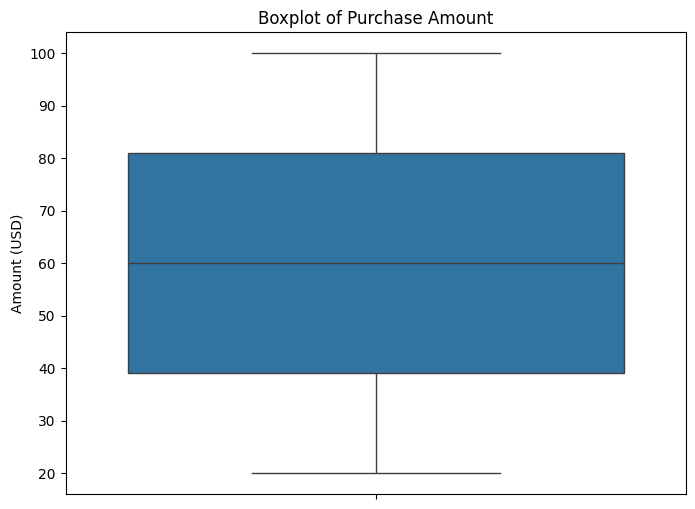

In [18]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Purchase Amount (USD)'])
plt.title('Boxplot of Purchase Amount')
plt.ylabel('Amount (USD)')
plt.show()

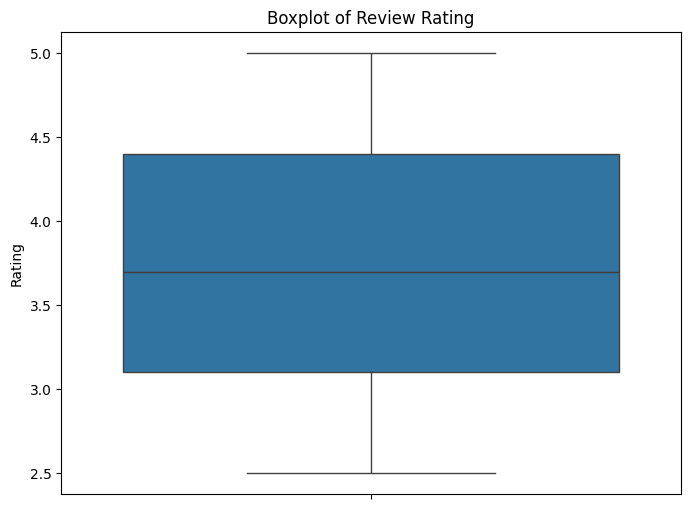

In [19]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Review Rating'])
plt.title('Boxplot of Review Rating')
plt.ylabel('Rating')
plt.show()

# **Eksplorasi Data (EDA)**

## **Comparison/Perbandingan**

Tahap ini bertujuan untuk membandingkan kontribusi setiap kategori produk terhadap total pendapatan perusahaan. Berdasarkan visualisasi di atas, diperoleh wawasan sebagai berikut:

* Dominasi Kategori: Kategori Clothing merupakan penyumbang pendapatan terbesar dengan total penjualan mencapai lebih dari $104.000, jauh mengungguli kategori lainnya.

* Urutan Performa: Diikuti oleh Accessories di posisi kedua, sementara Footwear dan Outerwear berada di posisi bawah.

* Gap Penjualan: Terdapat selisih yang cukup signifikan antara kategori Clothing dengan Outerwear, yang mengindikasikan bahwa fokus utama pelanggan di platform ini adalah pada kebutuhan pakaian sehari-hari dan aksesoris.

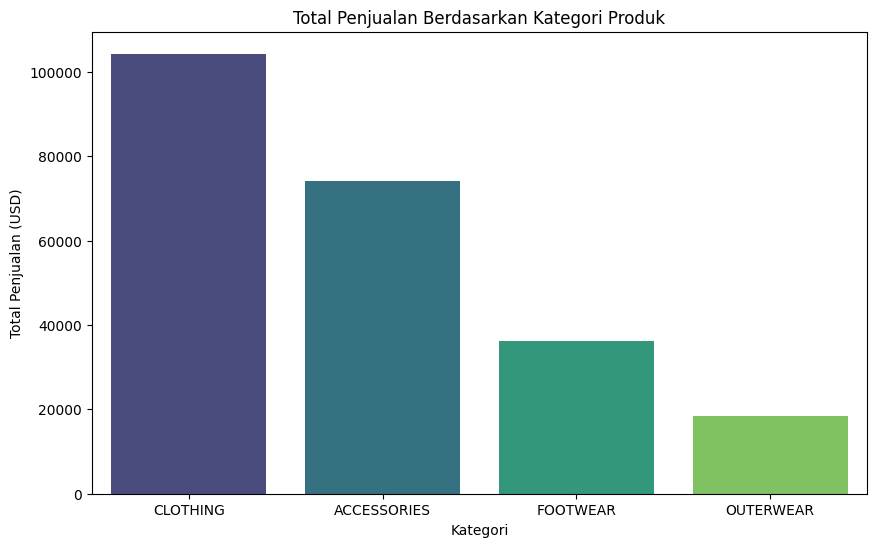

In [34]:
penjualan_kategori = df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=penjualan_kategori.index,
            y=penjualan_kategori.values,
            palette='viridis',
            hue=penjualan_kategori.index,
            legend=False)

plt.title('Total Penjualan Berdasarkan Kategori Produk')
plt.xlabel('Kategori')
plt.ylabel('Total Penjualan (USD)')
plt.show()

## **Composition/Komposisi**

Analisis ini bertujuan untuk melihat kontribusi relatif dari tiga kategori produk teratas terhadap total pendapatan yang dihasilkan dari kelompok produk paling laku. Berdasarkan grafik pie chart di atas, didapatkan poin-poin berikut:

* Pemain Utama (Clothing): Kategori Clothing memegang kendali hampir separuh dari total penjualan top 3 kategori (sekitar 48.6%). Ini menegaskan bahwa pakaian adalah komoditas paling krusial dalam bisnis ini.

* Aksesoris sebagai Pelengkap Kuat: Accessories menempati posisi kedua dengan proporsi 34.6%. Hal ini menunjukkan pelanggan memiliki minat yang tinggi untuk membeli barang tambahan selain pakaian utama.

* Footwear (Alas Kaki): Berada di posisi ketiga dengan kontribusi 16.8%. Meskipun paling kecil di antara ketiganya, kategori ini tetap menjadi pilar penting dalam portofolio produk perusahaan.

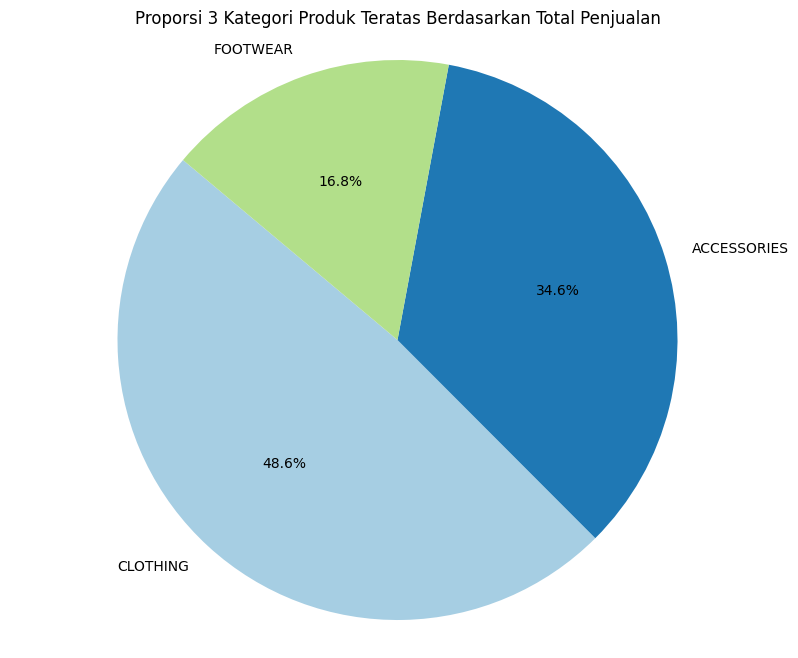

In [35]:
sales_by_category = df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
sales_by_category_top3 = sales_by_category.head(3)

plt.figure(figsize=(10, 8))
sales_by_category_top3.plot(kind='pie',
                            autopct='%1.1f%%',
                            startangle=140,
                            colors=plt.cm.Paired.colors)

plt.title('Proporsi 3 Kategori Produk Teratas Berdasarkan Total Penjualan')
plt.ylabel('')
plt.axis('equal')
plt.show()

## **Distribution/Distribusi**

* Aktivitas: Menganalisis penyebaran nilai transaksi pada kolom Purchase Amount (USD).
* Tujuan: Melihat pola belanja pelanggan, apakah mayoritas melakukan transaksi dalam nominal kecil atau besar, serta mengidentifikasi kecondongan (skewness) pada data pengeluaran untuk menentukan strategi penetapan harga.
* Visualisasi: Histogram dengan Kernel Density Estimation (KDE).

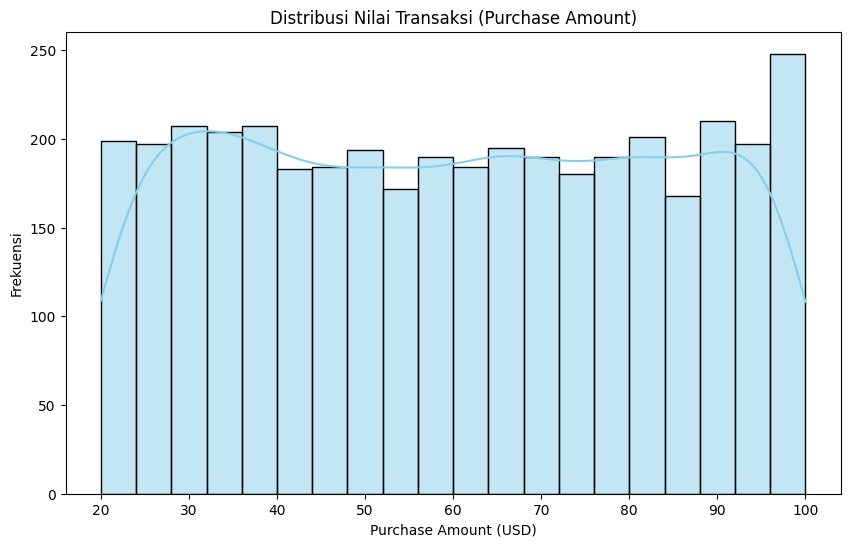

In [36]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Purchase Amount (USD)'], bins=20, kde=True, color='skyblue')
plt.title('Distribusi Nilai Transaksi (Purchase Amount)')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Frekuensi')
plt.show()

## **Relationship/Hubungan**

* Aktivitas: Menganalisis hubungan (korelasi) antar variabel numerik dalam dataset menggunakan Pearson Correlation.
* Tujuan: Mengidentifikasi apakah ada keterkaitan kuat antar variabel, misalnya apakah usia (Age) memengaruhi jumlah belanja (Purchase Amount) atau apakah pelanggan yang sering belanja (Previous Purchases) memberikan rating yang lebih tinggi.
* Visualisasi: Heatmap Correlation.

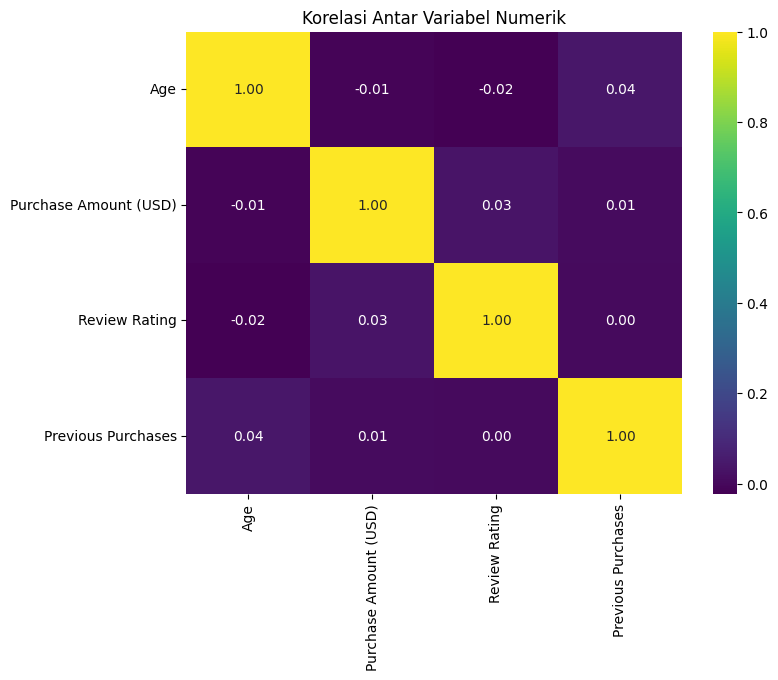

In [37]:
numeric_cols = df[['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']]

plt.figure(figsize=(8, 6))
sns.heatmap(data=numeric_cols.corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')

plt.title('Korelasi Antar Variabel Numerik')
plt.show()

# **Data Preparation**

## **Data Type**

## **Incosistent Values**

Langkah ini dilakukan untuk Melakukan pengecekan pada setiap kolom yang bertipe data object untuk memastikan tidak adanya perbedaan penulisan nilai yang maknanya sama.

dengan Tujuan Mencegah terjadinya duplikasi kategori yang disebabkan oleh perbedaan penggunaan huruf kapital, spasi tambahan di kalimat, atau kesalahan penulisan.

In [38]:
# Mengubah format teks pada kolom Category menjadi huruf besar (Upper Case)
df['Category'] = df['Category'].str.upper()

# Menampilkan nilai unik untuk memastikan konsistensi
print(df['Category'].unique())

# Mengubah format teks pada kolom Item Purchased menjadi huruf besar (Upper Case)
df['Item Purchased'] = df['Item Purchased'].str.upper()

# Menampilkan data untuk pengecekan hasil
df['Item Purchased'].head()

['CLOTHING' 'FOOTWEAR' 'OUTERWEAR' 'ACCESSORIES']


,Item Purchased
0,BLOUSE
1,SWEATER
2,JEANS
3,SANDALS
4,BLOUSE


Berdasarkan hasil eksekusi kode di atas, didapatkan temuan sebagai berikut:

* Kolom Category: Terdiri dari 4 nilai unik (Clothing, Accessories, Footwear, Outerwear) dengan format penulisan yang sudah seragam.

* Kolom Gender & Season: Tidak ditemukan adanya variasi penulisan yang salah. Semua data sudah konsisten.

* Whitespaces: Tidak ditemukan spasi tersembunyi yang membuat data terpecah.

Kesimpulan:

Data pada dataset ini memiliki tingkat konsistensi yang sangat tinggi. Meskipun demikian, pengecekan tetap dilakukan sebagai prosedur standar Data Preparation untuk menjaga integritas data sebelum masuk ke tahap pemodelan atau visualisasi.

## **Missing Values**

Langkah ini dilakukan untuk mendeteksi apakah terdapat data yang kosong pada dataset. Jika ditemukan, kita akan mengambil keputusan apakah data tersebut akan dihapus atau diimputasi berdasarkan persentase kerusakannya.

In [39]:
print((df.isna().sum() / len(df)) * 100)

Customer ID               0.0
Age                       0.0
Gender                    0.0
Item Purchased            0.0
Category                  0.0
Purchase Amount (USD)     0.0
Location                  0.0
Size                      0.0
Color                     0.0
Season                    0.0
Review Rating             0.0
Subscription Status       0.0
Shipping Type             0.0
Discount Applied          0.0
Promo Code Used           0.0
Previous Purchases        0.0
Payment Method            0.0
Frequency of Purchases    0.0
Spending Category         0.0
dtype: float64


1. Analisis Seluruh Kolom

Berdasarkan hasil eksekusi di atas, seluruh kolom (mulai dari Age hingga Frequency of Purchases) memiliki persentase data hilang sebesar 0%. Artinya, tidak ada satu pun baris data yang kosong atau hilang dalam dataset ini.

2. Penanganan Data

Karena tidak ada data yang hilang (0%), maka kita tidak perlu melakukan tindakan penghapusan kolom (dropping) maupun pengisian nilai rata-rata (imputation). Hal ini menunjukkan kualitas dataset yang sangat baik untuk dianalisis lebih lanjut.

3. Mengecek Missing Values Kembali

Untuk memastikan kembali kebersihan data setelah tahap pra-pemrosesan, kita lakukan pengecekan akhir.

In [40]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio %'])

,Null Ratio %
Customer ID,0.0
Age,0.0
Gender,0.0
Item Purchased,0.0
Category,0.0
Purchase Amount (USD),0.0
Location,0.0
Size,0.0
Color,0.0
Season,0.0


Kesimpulan:

Dataset dinyatakan bersih sepenuhnya dari missing values. Dengan kondisi data yang lengkap (100% terisi), kita dapat menjamin bahwa hasil analisis statistik dan visualisasi nantinya akan mencerminkan kondisi populasi pelanggan secara akurat tanpa adanya bias akibat data hilang.

## **Duplicated Values**

Melakukan pengecekan pada seluruh baris dataset untuk memastikan tidak ada entri data yang tercatat lebih dari satu kali dengan nilai yang identik di semua kolom.

Tujuan untuk Mencegah terjadinya anomali pada hasil analisis, seperti penggelembungan jumlah transaksi atau total pendapatan yang tidak sesuai dengan realita.

In [41]:
df[df.duplicated()]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Spending Category


1. Baris Duplikat

Berdasarkan hasil pengecekan, dataset ini memiliki 0 baris duplikat. Artinya, setiap baris data mewakili satu transaksi unik dari pelanggan yang berbeda.

In [42]:
df = df.drop_duplicates()

2. Mengecek Kembali Duplikasi

Setelah dilakukan fungsi drop, kita pastikan kembali bahwa sudah tidak ada baris yang ganda di dalam dataset.

In [43]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


Kesimpulan:

Dataset ini tidak mengandung data duplikat. Hal ini menjamin bahwa setiap data yang diolah adalah unik dan valid, sehingga hasil perhitungan statistik (seperti rata-rata pengeluaran per pelanggan) akan memberikan gambaran bisnis yang akurat.

## **Outliers Values**

Melakukan analisis pada kolom numerik untuk mendeteksi adanya data outliers yang nilainya berada di luar batas kewajaran.

Tujuan untuk Memastikan distribusi data tetap terjaga sehingga tidak ada nilai ekstrem yang dapat mengacaukan hasil perhitungan statistik maupun model analisis.

In [44]:
results = []
cols = df.select_dtypes(include=['float64', 'int64']).drop(columns=['Customer ID'], errors='ignore')

for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    percent_outliers = (len(outliers) / len(df)) * 100
    results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)
display(results_df)

Kolom,Persentase Outliers
Age,0.0
Purchase Amount (USD),0.0
Review Rating,0.0
Previous Purchases,0.0


1. Purchase Amount (USD)

Pada kolom ini, persentase data outliers adalah 0%. Nilai transaksi pelanggan berada dalam rentang yang stabil antara 20usd hingga 100usd, sehingga tidak ditemukan adanya anomali data.

2. Handling Outliers (Capping)

Meskipun hasil deteksi menunjukkan 0% outliers, kita tetap menerapkan fungsi clipping (pembatasan nilai) sebagai langkah preventif untuk menjaga konsistensi data di masa depan.

metode IQR (Interquartile Range) adalah cara untuk menentukan "pagar pembatas" agar kita bisa membedakan mana data yang masih dianggap wajar dan mana data yang sudah dianggap aneh (outlier). Metode ini bekerja dengan mengabaikan data yang terlalu pendek atau terlalu tinggi, dan hanya fokus pada 50% data di bagian tengah (pusat sebaran data).

Mengapa metode IQR adalah cara paling objektif untuk membersihkan data dari gangguan nilai ekstrem? karena batasnya ditentukan oleh karakteristik data itu sendiri, bukan sekadar tebakan manusia.

In [45]:
Q1 = df['Purchase Amount (USD)'].quantile(0.25)
Q3 = df['Purchase Amount (USD)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].clip(lower=lower_bound, upper=upper_bound)

Kesimpulan:

Seluruh variabel numerik dalam dataset ini memiliki kualitas distribusi yang sangat baik dengan 0% outliers. Dengan tidak adanya nilai ekstrem, data ini sangat reliabel untuk digunakan dalam tahap analisis korelasi maupun perancangan strategi bisnis ke depannya.

# **Construct Data**

Pada tahap ini, kita akan membuat kolom baru berdasarkan kriteria dari kolom yang sudah ada. Hal ini bertujuan untuk memperkaya dataset sehingga kita bisa melakukan analisis segmentasi yang lebih mendalam.

Tujuan Untuk Mengelompokkan pelanggan ke dalam kategori pengeluaran (Low, Medium, High) untuk mempermudah identifikasi target pasar berdasarkan daya beli.

In [46]:
def kategori_spending(amount):
    if amount < 40:
        return 'Economy'
    elif amount <= 75:
        return 'Mid-Range'
    else:
        return 'Premium'

df['Spending Category'] = df['Purchase Amount (USD)'].apply(kategori_spending)

display(df[['Purchase Amount (USD)', 'Spending Category']].head())

,Purchase Amount (USD),Spending Category
0,53,Mid-Range
1,64,Mid-Range
2,73,Mid-Range
3,90,Premium
4,49,Mid-Range


1. Analisis Spending Category

Berdasarkan fungsi yang telah dibuat, kita sekarang memiliki dimensi baru untuk melihat profil pelanggan. Transaksi di bawah 40usd masuk kategori Economy, antara  40 - 75 masuk Mid-Range, dan di atas 75usd masuk kategori Premium.

2. Verifikasi Hasil

Kita pastikan kolom baru sudah terbentuk dengan benar dan tidak memiliki nilai kosong.

In [47]:
spending_counts = df['Spending Category'].value_counts().reset_index()
spending_counts.columns = ['Spending Category', 'Total Customers']
display(spending_counts)

,Spending Category,Total Customers
0,Mid-Range,1672
1,Premium,1214
2,Economy,1014


Kesimpulan:

Dengan adanya kolom Spending Category, kita tidak hanya melihat angka nominal saja, tetapi bisa langsung mengelompokkan pelanggan ke dalam segmen daya beli. Hal ini sangat berguna untuk menentukan strategi promosi, misalnya memberikan diskon khusus untuk segmen Economy agar lebih sering belanja, atau menawarkan produk eksklusif untuk segmen Premium.

# **Reduct Data**

Melakukan penghapusan kolom yang tidak relevan atau tidak memberikan kontribusi signifikan terhadap proses analisis dan pemodelan data.

Tujuan untuk Menyederhanakan dataset agar lebih efisien dalam penggunaan memori dan memastikan analisis terfokus pada variabel-variabel yang memiliki pengaruh nyata terhadap perilaku belanja pelanggan.

In [48]:
df = df.drop('Customer ID', axis=1)

df = df.drop('Promo Code Used', axis=1)

df = df.drop('Color', axis=1)

display(df.head())

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases,Spending Category
0,55,Male,BLOUSE,CLOTHING,53,Kentucky,L,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Mid-Range
1,19,Male,SWEATER,CLOTHING,64,Maine,L,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Mid-Range
2,50,Male,JEANS,CLOTHING,73,Massachusetts,S,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Mid-Range
3,21,Male,SANDALS,FOOTWEAR,90,Rhode Island,M,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Premium
4,45,Male,BLOUSE,CLOTHING,49,Oregon,M,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Mid-Range


1. Customer Id

Kolom Customer ID dihapus karena nilainya bersifat unik untuk setiap entri dan tidak memberikan informasi mengenai tren atau pola perilaku kelompok pelanggan. Mempertahankan kolom ini dalam tahap analisis lanjut hanya akan menambah beban komputasi tanpa memberikan insight strategis.

2. Promo Code Used

Kolom ini memiliki korelasi 100% dengan kolom Discount Applied. Karena informasinya redudan (berulang), kita hanya perlu mempertahankan salah satu sebagai indikator penggunaan promo agar analisis lebih efisien.

3. Color
Kolom ini berisi detail variasi warna produk yang sangat beragam. Untuk analisis perilaku belanja tingkat makro, detail warna seringkali tidak memberikan pengaruh signifikan terhadap tren profitabilitas secara umum, sehingga bisa direduksi untuk mempercepat proses komputasi.

#**Visualisasi Matplotlib & Seaborn**

##**BAR CHART**

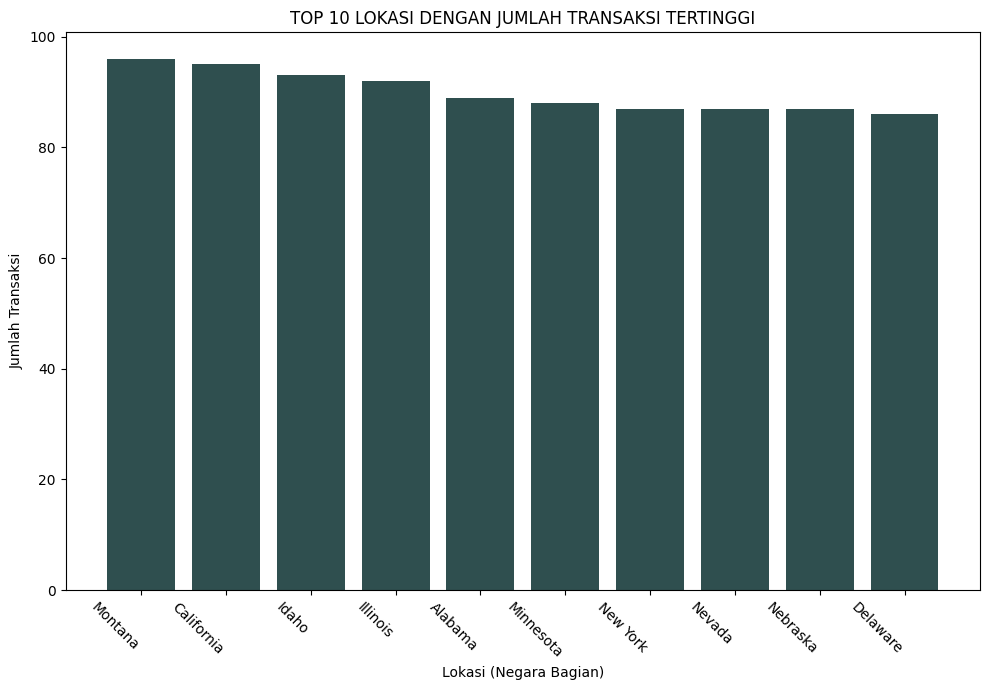

In [53]:
top10_lokasi = df['Location'].value_counts().head(10).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
plt.bar(top10_lokasi.index, top10_lokasi.values, color='darkslategray')

plt.xlabel('Lokasi (Negara Bagian)')
plt.ylabel('Jumlah Transaksi')
plt.title('TOP 10 LOKASI DENGAN JUMLAH TRANSAKSI TERTINGGI')
plt.xticks(rotation=-45, ha='right')

plt.tight_layout()
plt.show()

Berdasarkan visualisasi di atas (Matplotlib) , Montana dan California muncul sebagai wilayah dengan frekuensi transaksi tertinggi, yakni masing-masing mencapai 96 dan 95 transaksi, yang mengindikasikan dominasi pasar yang kuat di kedua negara bagian tersebut. Distribusi transaksi pada sepuluh besar lokasi ini terlihat cukup kompetitif dengan selisih yang sangat tipis antar wilayah, sehingga manajemen dapat memfokuskan strategi distribusi logistik dan kampanye pemasaran lokal yang lebih intensif pada area-area ini untuk mempertahankan momentum pertumbuhan volume penjualan.

##**PIE CHART**

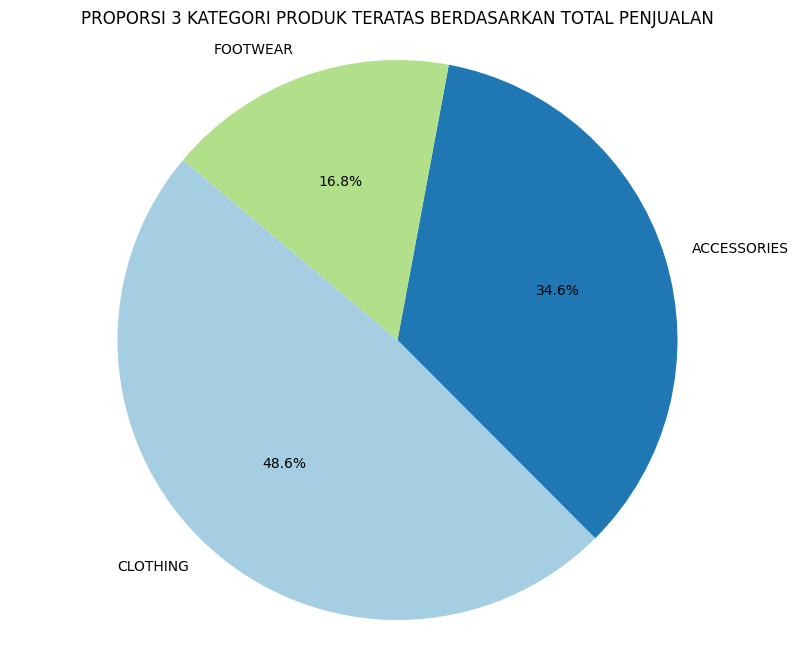

In [55]:
sales_by_category = df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
sales_by_category_top3 = sales_by_category.head(3)

colors = sns.color_palette('pastel')[0:3]

plt.figure(figsize=(10, 8))
sales_by_category_top3.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)

plt.title('PROPORSI 3 KATEGORI PRODUK TERATAS BERDASARKAN TOTAL PENJUALAN')
plt.ylabel('')
plt.axis('equal')
plt.show()

Visualisasi menunjukkan bahwa kategori CLOTHING mendominasi pasar dengan kontribusi hampir separuh dari total penjualan tiga besar (48.6%), yang menegaskan bahwa produk pakaian merupakan penggerak utama (primary driver) pendapatan bisnis. Sementara itu, kategori ACCESSORIES memberikan kontribusi signifikan sebesar 34.6%, menunjukkan potensi besar dalam strategi bundling produk, sedangkan FOOTWEAR melengkapi komposisi dengan 16.8%, sehingga fokus inventaris dan kampanye promosi sebaiknya diprioritaskan pada dua kategori teratas guna memaksimalkan profitabilitas.

##**LINE CHART**

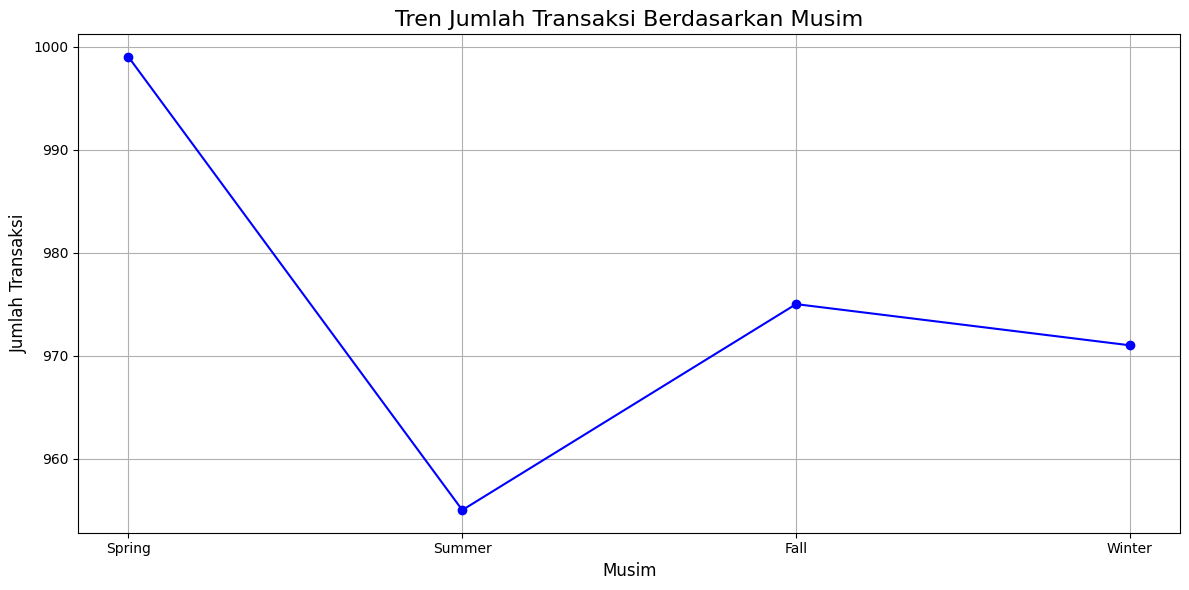

In [56]:
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
if df['Season'].str.isupper().all():
    season_order = [s.upper() for s in season_order]

grup_season = df.groupby('Season').size().reindex(season_order)

plt.figure(figsize=(12, 6))
plt.plot(grup_season.index, grup_season.values, marker='o', color='blue')

plt.title('Tren Jumlah Transaksi Berdasarkan Musim', fontsize=16)
plt.xlabel('Musim', fontsize=12)
plt.ylabel('Jumlah Transaksi', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

Visualisasi tren menunjukkan bahwa aktivitas belanja mencapai puncaknya pada musim semi (999 transaksi) dan cenderung mengalami alur yang stabil di musim-musim berikutnya, dengan sedikit penurunan pada musim panas sebelum kembali stabil di angka sekitar 970-an transaksi pada musim gugur dan dingin. Konsistensi volume transaksi di sepanjang tahun ini mengindikasikan bahwa produk yang ditawarkan memiliki permintaan yang berkelanjutan (sustainable demand), sehingga perusahaan dapat mempertahankan strategi promosi yang stabil namun tetap perlu memberikan insentif tambahan pada musim Summer untuk memicu kembali pertumbuhan volume penjualan ke angka puncaknya.

##**HISTOGRAM**

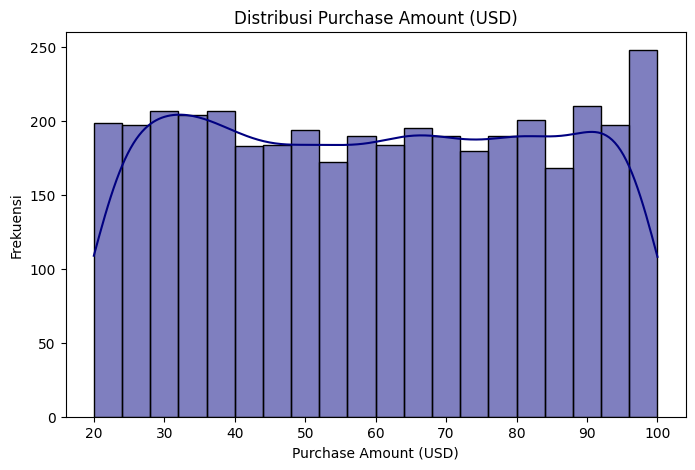

In [57]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Purchase Amount (USD)'], bins=20, kde=True, color='navy')

plt.title('Distribusi Purchase Amount (USD)') # Judul visualisasi
plt.xlabel('Purchase Amount (USD)') # Label sumbu X
plt.ylabel('Frekuensi') # Label sumbu Y
plt.show()

Visualisasi menunjukkan bahwa nilai transaksi (Purchase Amount) tersebar secara merata di seluruh rentang harga antara 20usd hingga 100usd tanpa adanya konsentrasi berlebih pada nilai tertentu, yang diperkuat dengan nilai skewness mendekati nol (0.01) yang menandakan distribusi data hampir simetris sempurna. Pola distribusi yang bersifat uniform ini mengindikasikan bahwa pelanggan memiliki daya beli yang sangat bervariasi secara proporsional, sehingga perusahaan memiliki fleksibilitas tinggi dalam menawarkan produk di berbagai titik harga tanpa khawatir akan dominasi segmen harga tunggal yang terlalu ekstrim.

##**BOX PLOT**

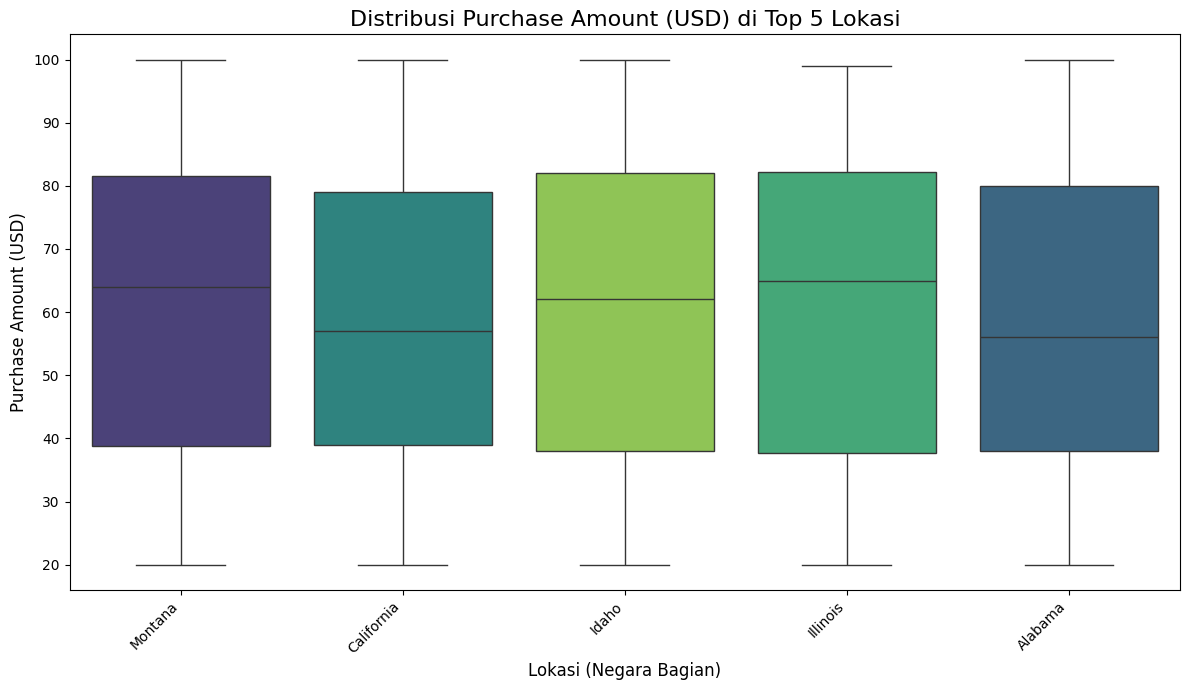

In [62]:
# Identifikasi 5 lokasi teratas berdasarkan jumlah transaksi
top5_lokasi = df['Location'].value_counts().head(5).index

df_top5 = df[df['Location'].isin(top5_lokasi)]

plt.figure(figsize=(12, 7))
sns.boxplot(x='Location', y='Purchase Amount (USD)', data=df_top5, palette='viridis', order=top5_lokasi, hue='Location')

plt.title('Distribusi Purchase Amount (USD) di Top 5 Lokasi', fontsize=16) # Judul
plt.xlabel('Lokasi (Negara Bagian)', fontsize=12) # Label X
plt.ylabel('Purchase Amount (USD)', fontsize=12) # Label Y
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Berdasarkan visualisasi boxplot (seaborn) di atas, terlihat bahwa sebaran nilai transaksi pada lima lokasi teratas (Montana, California, Idaho, Illinois, dan Alabama) memiliki rentang yang sangat konsisten dengan nilai median yang stabil di kisaran 56usd hingga 65usd. Tidak ditemukannya titik pencilan (outliers) pada kelima wilayah tersebut menunjukkan bahwa daya beli pelanggan di lokasi-lokasi dengan volume transaksi tertinggi ini cenderung homogen dan dapat diprediksi, sehingga perusahaan dapat menerapkan standarisasi harga dan promosi yang serupa tanpa perlu melakukan penyesuaian nilai transaksi yang signifikan antar wilayah tersebut.

##**SCATTER PLOT**

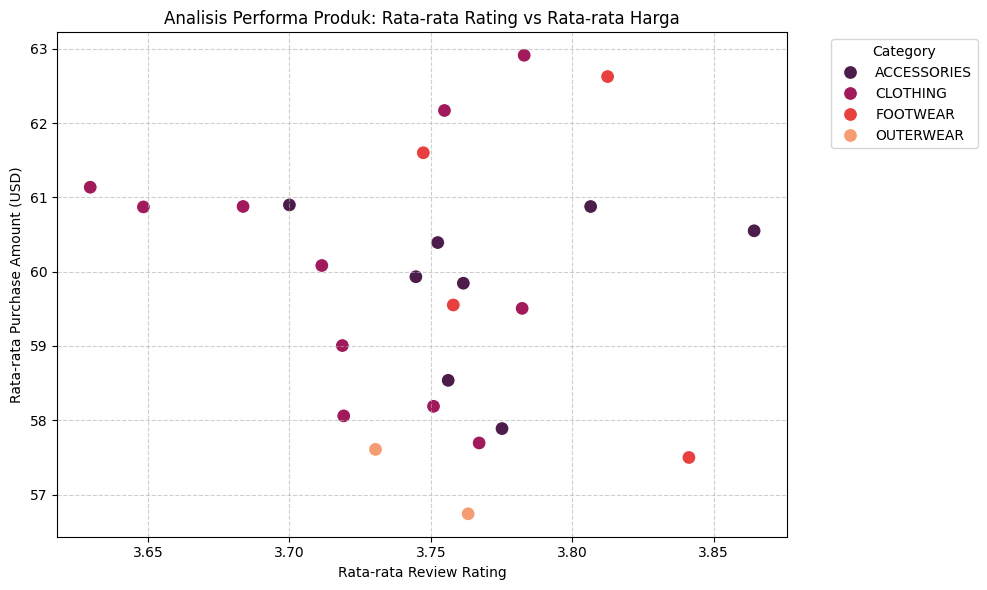

In [60]:
item_stats = df.groupby(['Item Purchased', 'Category']).agg({'Review Rating': 'mean','Purchase Amount (USD)': 'mean'}).reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Review Rating', y='Purchase Amount (USD)', hue='Category', palette='rocket', data=item_stats, s=100)

plt.title('Analisis Performa Produk: Rata-rata Rating vs Rata-rata Harga') # Judul
plt.xlabel('Rata-rata Review Rating') # Keterangan sumbu X
plt.ylabel('Rata-rata Purchase Amount (USD)') # Keterangan sumbu Y
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Visualisasi di atas menunjukkan performa setiap produk berdasarkan rata-rata kepuasan pelanggan dan nilai transaksi, di mana terlihat bahwa sebagian besar produk berkumpul pada rentang rating 3.65 hingga 3.85 dengan rata-rata harga di kisaran 57usd hingga 63usd. Tidak adanya korelasi linear yang kuat antara kedua variabel ini menandakan bahwa harga produk tidak secara langsung menentukan tinggi rendahnya rating yang diberikan pelanggan, sehingga manajemen dapat menyimpulkan bahwa persepsi nilai produk di mata konsumen bersifat stabil di seluruh kategori harga yang ditawarkan.

##**BUBBLE CHART**

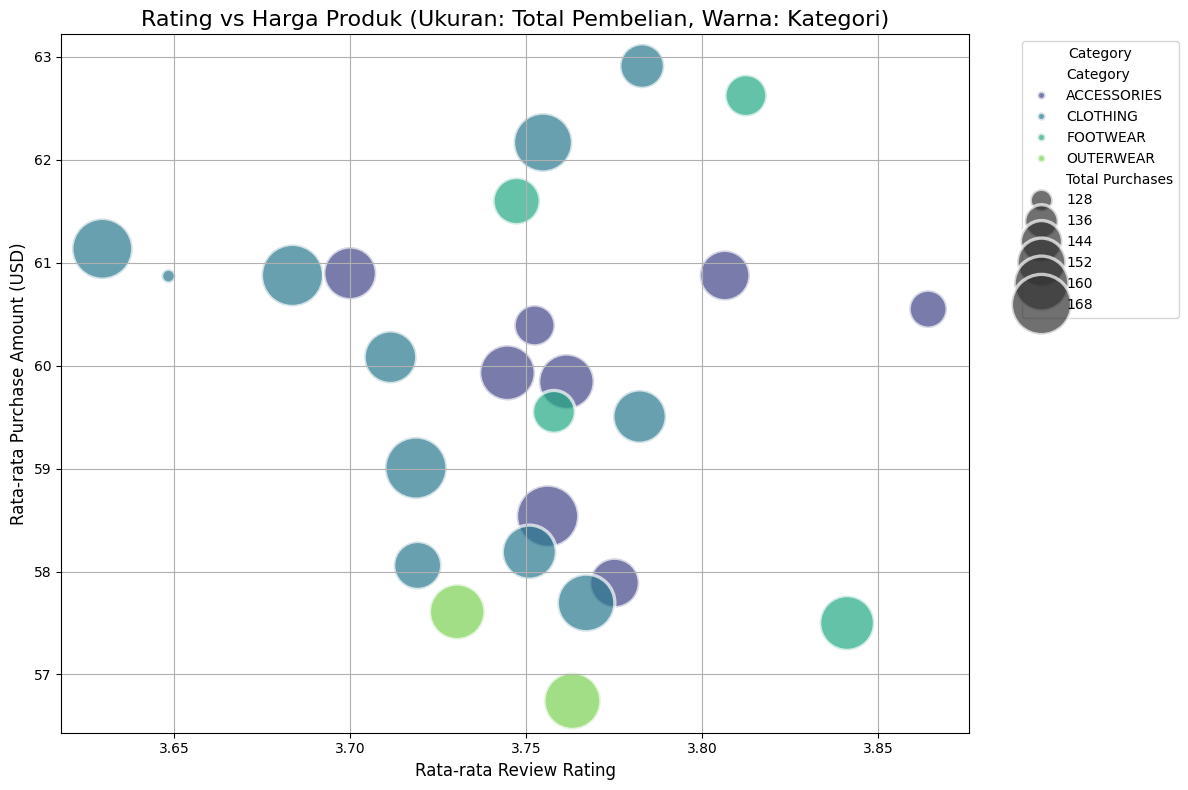

In [61]:
bubble_data = df.groupby(['Item Purchased', 'Category']).agg({
    'Review Rating': 'mean',
    'Purchase Amount (USD)': 'mean',
    'Item Purchased': 'count'
}).rename(columns={'Item Purchased': 'Total Purchases'}).reset_index()

plt.figure(figsize=(12, 8))
sns.scatterplot(x='Review Rating',
                y='Purchase Amount (USD)',
                size='Total Purchases',
                hue='Category',
                data=bubble_data,
                sizes=(100, 2000),
                alpha=0.7,
                palette='viridis')

plt.title('Rating vs Harga Produk (Ukuran: Total Pembelian, Warna: Kategori)', fontsize=16)
plt.xlabel('Rata-rata Review Rating', fontsize=12)
plt.ylabel('Rata-rata Purchase Amount (USD)', fontsize=12)
plt.grid(True)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Visualisasi bubble chart ini menunjukkan bahwa sebagian besar produk unggulan terkonsentrasi pada area dengan rating tinggi dan harga menengah, di mana ukuran gelembung yang relatif seragam mengindikasikan bahwa volume penjualan terdistribusi cukup merata di berbagai jenis produk tanpa adanya satu item yang mendominasi pasar secara ekstrim. Dominasi kategori Clothing (warna ungu/hijau tua) yang tersebar luas menunjukkan bahwa kategori ini merupakan tulang punggung bisnis dengan variasi harga dan rating yang stabil, sehingga perusahaan dapat menyimpulkan bahwa portofolio produk saat ini telah berhasil menjangkau berbagai preferensi konsumen dengan tingkat kepuasan yang konsisten.

##**HEATMAP**

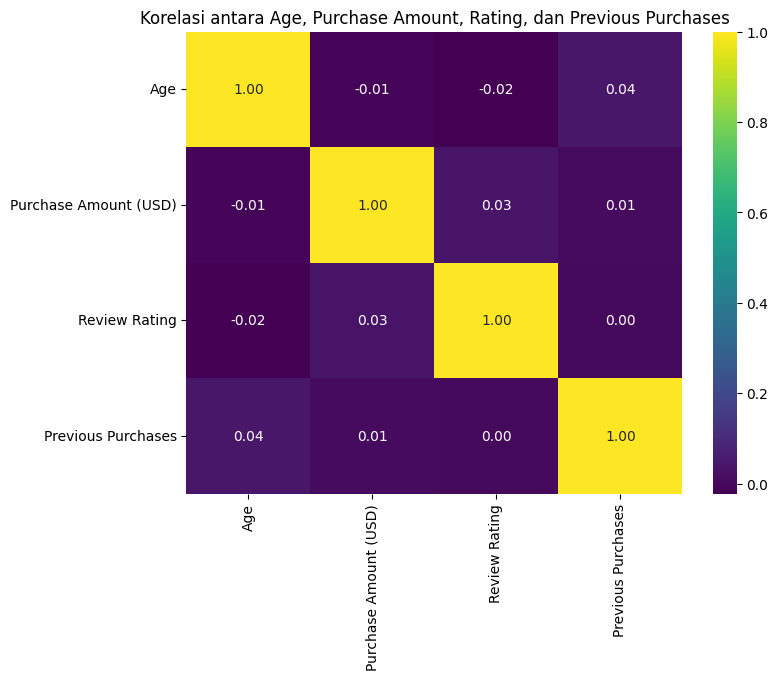

In [63]:
# Memilih kolom numerik yang tersedia
kolom_numerik = df[['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']]

plt.figure(figsize=(8, 6))
sns.heatmap(data=kolom_numerik.corr(),
            annot=True, # Menampilkan angka korelasi
            cmap='viridis',
            fmt='.2f')

plt.title('Korelasi antara Age, Purchase Amount, Rating, dan Previous Purchases')
plt.show()

Berdasarkan visualisasi heatmap di atas, terlihat bahwa seluruh variabel numerik memiliki nilai korelasi yang sangat mendekati nol (berkisar antara -0.01 hingga 0.03), yang mengindikasikan bahwa tidak terdapat hubungan linear yang signifikan antar variabel tersebut. Hal ini memberikan gambaran strategis bahwa perilaku belanja pelanggan bersifat independen; sebagai contoh, jumlah pengeluaran (Purchase Amount) tidak dipengaruhi oleh usia maupun loyalitas masa lalu (Previous Purchases), sehingga perusahaan perlu menerapkan strategi pemasaran yang lebih luas dan tidak hanya terpaku pada satu segmen demografis atau riwayat belanja tertentu saja.

# **Menyimpan DataSet Bersih**

In [51]:
df.to_csv("[CLEAN]Customer Behaviour and Shopping Analysis.csv", index=False)